#📌 Extracción

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# URL pública del JSON
API_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json" #Gracias por no hacerlo con endpoints y API Keys

def extraer_datos_desde_api(url):
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()  # Lanza error si la respuesta HTTP no es 200
        datos = response.json()
        print("Extracción exitosa desde la API.")
        return datos
    except requests.exceptions.RequestException as e:
        print(f"Error en la extracción: {e}")
        return None

# Ejecutar extracción
datos_brutos = extraer_datos_desde_api(API_URL)

# Validación inicial
if datos_brutos is not None:
    print(f"Cantidad de registros extraídos: {len(datos_brutos)}")
    print(f"Tipo de estructura recibida: {type(datos_brutos)}")
    print("Primer registro:")
    print(datos_brutos[0])

Extracción exitosa desde la API.
Cantidad de registros extraídos: 7267
Tipo de estructura recibida: <class 'list'>
Primer registro:
{'customerID': '0002-ORFBO', 'Churn': 'No', 'customer': {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}, 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'}, 'internet': {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}, 'account': {'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}}


#🔧 Transformación

In [4]:
# Normalizar JSON

df_raw = pd.json_normalize(datos_brutos, sep="_")

print("Dimensiones iniciales:", df_raw.shape)
display(df_raw.head())

# Copia de trabajo
df = df_raw.copy()

# Renombrar columnas para dejar nombres más limpios
df.columns = (
    df.columns
      .str.replace("customer_", "", regex=False)
      .str.replace("phone_", "", regex=False)
      .str.replace("internet_", "", regex=False)
      .str.replace("account_", "", regex=False)
      .str.replace("Charges_", "", regex=False)
)

df.rename(columns={
    "customerID": "customer_id",
    "SeniorCitizen": "senior_citizen",
    "Partner": "partner",
    "Dependents": "dependents",
    "tenure": "tenure_months",
    "PhoneService": "phone_service",
    "MultipleLines": "multiple_lines",
    "InternetService": "internet_service",
    "OnlineSecurity": "online_security",
    "OnlineBackup": "online_backup",
    "DeviceProtection": "device_protection",
    "TechSupport": "tech_support",
    "StreamingTV": "streaming_tv",
    "StreamingMovies": "streaming_movies",
    "Contract": "contract",
    "PaperlessBilling": "paperless_billing",
    "PaymentMethod": "payment_method",
    "Monthly": "monthly_charges",
    "Total": "total_charges",
    "Churn": "churn"
}, inplace=True)

# Limpiar espacios en blanco en columnas tipo texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Reemplazar strings vacíos por NaN
df.replace({"": np.nan}, inplace=True)

# Convertir columnas numéricas
df["tenure_months"] = pd.to_numeric(df["tenure_months"], errors="coerce")
df["monthly_charges"] = pd.to_numeric(df["monthly_charges"], errors="coerce")
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

# Estandarizar senior_citizen
df["senior_citizen"] = df["senior_citizen"].map({0: "No", 1: "Sí"})

# Estandarizar churn
df["churn"] = df["churn"].replace({"Yes": "Yes", "No": "No"})

# Crear columna binaria para análisis
df["churn_flag"] = df["churn"].map({"Yes": 1, "No": 0})

# Crear cargos diarios como variable derivada
df["daily_charges"] = (df["monthly_charges"] / 30).round(2)

# Crear grupo de antigüedad
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 meses", "13-24 meses", "25-48 meses", "49-72 meses"],
    include_lowest=True
)

# Verificaciones
print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nDuplicados en customer_id:", df["customer_id"].duplicated().sum())

print("\nTipos de datos:")
print(df.dtypes)

display(df.head())

Dimensiones iniciales: (7267, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



Valores nulos por columna:
customer_id            0
churn                224
gender                 0
senior_citizen         0
partner                0
dependents             0
tenure_months          0
phone_service          0
multiple_lines         0
internet_service       0
online_security        0
online_backup          0
device_protection      0
tech_support           0
streaming_tv           0
streaming_movies       0
contract               0
paperless_billing      0
payment_method         0
monthly_charges        0
total_charges         11
churn_flag           224
daily_charges          0
tenure_group           0
dtype: int64

Duplicados en customer_id: 0

Tipos de datos:
customer_id            object
churn                  object
gender                 object
senior_citizen         object
partner                object
dependents             object
tenure_months           int64
phone_service          object
multiple_lines         object
internet_service       object
online_secur

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_flag,daily_charges,tenure_group
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0,2.19,0-12 meses
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0,2.00,0-12 meses
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0,2.46,0-12 meses
3,0011-IGKFF,Yes,Male,Sí,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0,3.27,13-24 meses
4,0013-EXCHZ,Yes,Female,Sí,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1.0,2.80,0-12 meses


#📊 Carga y análisis

Archivo exportado correctamente: telecomx_etl_limpio.csv
Total de clientes analizados: 7043
Clientes con churn: 1869.0
Tasa general de churn: 26.54%

Tasa de churn por contrato:
contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%
Name: churn_flag, dtype: object

Tasa de churn por servicio de internet:
internet_service
Fiber optic    41.89%
DSL            18.96%
No               7.4%
Name: churn_flag, dtype: object

Tasa de churn por método de pago:
payment_method
Electronic check             45.29%
Mailed check                 19.11%
Bank transfer (automatic)    16.71%
Credit card (automatic)      15.24%
Name: churn_flag, dtype: object


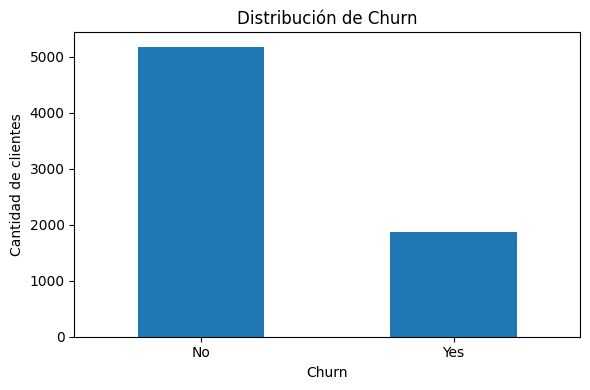

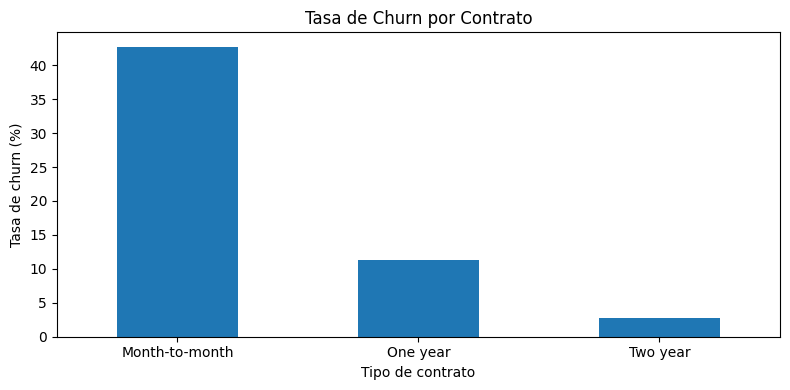

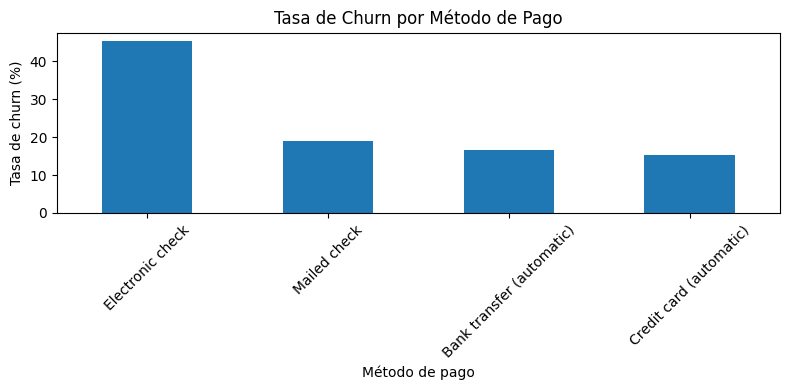

In [5]:
# Guardar resultado procesado
archivo_salida = "telecomx_etl_limpio.csv"
df.to_csv(archivo_salida, index=False, encoding="utf-8")

print(f"Archivo exportado correctamente: {archivo_salida}")

# Dataset para análisis
df_analisis = df.dropna(subset=["churn"]).copy()

# Métricas generales
total_clientes = len(df_analisis)
clientes_churn = df_analisis["churn_flag"].sum()
tasa_churn = df_analisis["churn_flag"].mean()

print(f"Total de clientes analizados: {total_clientes}")
print(f"Clientes con churn: {clientes_churn}")
print(f"Tasa general de churn: {tasa_churn:.2%}")

# Churn por contrato
churn_por_contrato = (
    df_analisis.groupby("contract")["churn_flag"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTasa de churn por contrato:")
print((churn_por_contrato * 100).round(2).astype(str) + "%")

# Churn por internet
churn_por_internet = (
    df_analisis.groupby("internet_service")["churn_flag"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTasa de churn por servicio de internet:")
print((churn_por_internet * 100).round(2).astype(str) + "%")

# Churn por método de pago
churn_por_pago = (
    df_analisis.groupby("payment_method")["churn_flag"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTasa de churn por método de pago:")
print((churn_por_pago * 100).round(2).astype(str) + "%")

# Visualización 1
plt.figure(figsize=(6,4))
df_analisis["churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualización 2
plt.figure(figsize=(8,4))
(churn_por_contrato * 100).plot(kind="bar")
plt.title("Tasa de Churn por Contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Tasa de churn (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualización 3
plt.figure(figsize=(8,4))
(churn_por_pago * 100).plot(kind="bar")
plt.title("Tasa de Churn por Método de Pago")
plt.xlabel("Método de pago")
plt.ylabel("Tasa de churn (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#📄Informe final

In [6]:
print("INFORME FINAL DEL ETL - TELECOM X")
print("=" * 50)

print("\n1. Extracción")
print("- Los datos fueron consumidos desde una API pública en formato JSON.")
print(f"- Se extrajeron {len(datos_brutos)} registros.")

print("\n2. Transformación")
print("- Se aplanó la estructura anidada del JSON.")
print("- Se renombraron columnas para facilitar el análisis.")
print("- Se limpiaron valores vacíos y espacios en blanco.")
print("- Se convirtieron variables numéricas y se crearon variables derivadas como daily_charges y tenure_group.")

print("\n3. Carga")
print(f"- El dataset limpio fue exportado como: {archivo_salida}")

print("\n4. Hallazgos principales")
print(f"- La tasa general de churn es: {tasa_churn:.2%}")
print(f"- El tipo de contrato con mayor churn es: {churn_por_contrato.idxmax()} ({churn_por_contrato.max():.2%})")
print(f"- El método de pago con mayor churn es: {churn_por_pago.idxmax()} ({churn_por_pago.max():.2%})")
print(f"- El servicio de internet con mayor churn es: {churn_por_internet.idxmax()} ({churn_por_internet.max():.2%})")

print("\n5. Conclusión")
print("- Los clientes con contratos más flexibles, ciertos métodos de pago y determinados servicios presentan mayor riesgo de cancelación.")
print("- El ETL permitió convertir datos semiestructurados en una base lista para análisis y visualización.")

INFORME FINAL DEL ETL - TELECOM X

1. Extracción
- Los datos fueron consumidos desde una API pública en formato JSON.
- Se extrajeron 7267 registros.

2. Transformación
- Se aplanó la estructura anidada del JSON.
- Se renombraron columnas para facilitar el análisis.
- Se limpiaron valores vacíos y espacios en blanco.
- Se convirtieron variables numéricas y se crearon variables derivadas como daily_charges y tenure_group.

3. Carga
- El dataset limpio fue exportado como: telecomx_etl_limpio.csv

4. Hallazgos principales
- La tasa general de churn es: 26.54%
- El tipo de contrato con mayor churn es: Month-to-month (42.71%)
- El método de pago con mayor churn es: Electronic check (45.29%)
- El servicio de internet con mayor churn es: Fiber optic (41.89%)

5. Conclusión
- Los clientes con contratos más flexibles, ciertos métodos de pago y determinados servicios presentan mayor riesgo de cancelación.
- El ETL permitió convertir datos semiestructurados en una base lista para análisis y visua